In [33]:
pip install tensorflow matplotlib numpy

**Import Required Libraries**

In [34]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
DATASET_PATH = "/content/drive/MyDrive/Alzheimer (Preprocessed Data)"

In [37]:
import os

print("Folder Exists:", os.path.exists(DATASET_PATH))
print("Folders Inside:", os.listdir(DATASET_PATH))

Folder Exists: True
Folders Inside: ['Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented', 'Mild_Demented']


**Define Image Parameters**

In [38]:
IMG_SIZE = 224
BATCH_SIZE = 32

**Create Data Generators (Train + Validation)**

In [39]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

**Load Training Data**

In [40]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 5138 images belonging to 4 classes.


**Load Validation Data**

In [41]:
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Class Labels:", train_generator.class_indices)

Found 1283 images belonging to 4 classes.
Class Labels: {'Mild_Demented': 0, 'Moderate_Demented': 1, 'Non_Demented': 2, 'Very_Mild_Demented': 3}


In [42]:
print(train_generator.class_indices)

{'Mild_Demented': 0, 'Moderate_Demented': 1, 'Non_Demented': 2, 'Very_Mild_Demented': 3}


**Balance Classes**

In [43]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.7914923291492328), 1: np.float64(24.701923076923077), 2: np.float64(0.4984478075281335), 3: np.float64(0.716796875)}


**Build Transfer Learning Model (RESNET)**

In [44]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Fine-tuning (VERY IMPORTANT)
base_model.trainable = True

# Freeze first 140 layers, train remaining
for layer in base_model.layers[:140]:
    layer.trainable = False

**Build Model**

In [45]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


**Compile Model**

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 15,507,716 (59.16 MB)

 Non-trainable params: 8,613,760 (32.86 MB)

**Callback**

In [47]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [48]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

**Train Model**

In [50]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 613ms/step - accuracy: 0.5977 - loss: 0.8702 - val_accuracy: 0.4817 - val_loss: 1.6497
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 613ms/step - accuracy: 0.5981 - loss: 0.8522 - val_accuracy: 0.4599 - val_loss: 2.1044
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 616ms/step - accuracy: 0.6032 - loss: 0.8486 - val_accuracy: 0.4942 - val_loss: 1.8597
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 615ms/step - accuracy: 0.6261 - loss: 0.8246 - val_accuracy: 0.2619 - val_loss: 2.4782
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 98s 608ms/step - accuracy: 0.6129 - loss: 0.8261 - val_accuracy: 0.4638 - val_loss: 1.5264
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 98s 605ms/step - accuracy: 0.6183 - loss: 0.8235 - val_accuracy: 0.5035 - val_loss: 1.8613
Epoch 7/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 98s 610ms/step - accuracy: 0.6234 - loss: 0.8154 - val_accuracy: 0.3523 - val_loss: 2.8234
Epoch 8/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 98s 607ms/step - accuracy: 0.6253 - loss: 0

**Accuracy Plot**

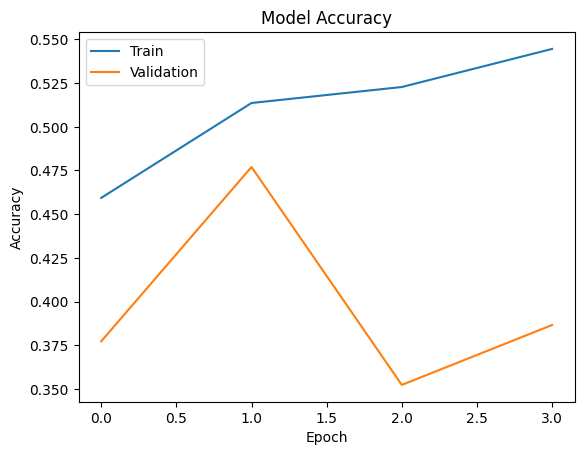

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

**Loss Plot**

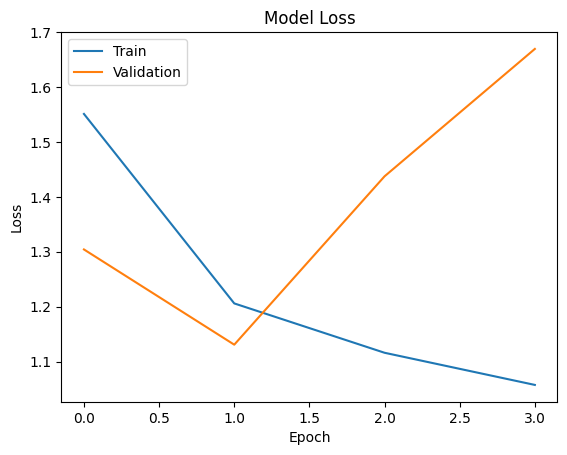

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

**Save Model**

In [26]:
model.save("alzheimers_model.h5")
print("Model Saved Successfully!")

Model Saved Successfully!


In [27]:
!pip install streamlit pyngrok tensorflow pillow numpy reportlab pytz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 109.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from datetime import datetime
import pytz
import time
import io
import base64

# PDF — professional layout
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    HRFlowable, KeepTogether
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import mm
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_RIGHT

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(page_title="NEXUS", page_icon="🧠", layout="wide")

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600;700&family=Fraunces:ital,opsz,wght@0,9..144,300;0,9..144,600;0,9..144,700;1,9..144,300&display=swap');

@keyframes gradientShift {
    0%   { background-position: 0% 50%; }
    50%  { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}
.stApp {
    background: linear-gradient(-45deg, #a8edca, #c9f0df, #f1edea, #d4e9f7, #b8dfc9);
    background-size: 400% 400%;
    animation: gradientShift 12s ease infinite;
    font-family: 'DM Sans', sans-serif;
}
.block-container { padding: 2.5rem 4rem; }

@keyframes fadeInUp {
    from { opacity: 0; transform: translateY(22px); }
    to   { opacity: 1; transform: translateY(0); }
}
.fade-in   { animation: fadeInUp 0.65s ease both; }
.fade-in-1 { animation-delay: 0.05s; }
.fade-in-2 { animation-delay: 0.15s; }
.fade-in-3 { animation-delay: 0.25s; }
.fade-in-4 { animation-delay: 0.35s; }

.main-title {
    font-family: 'Fraunces', serif;
    font-size: 44px; font-weight: 600; font-optical-sizing: auto;
    background: linear-gradient(135deg, #1a6e4a, #2563eb);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    display: flex; align-items: center; gap: 14px;
    animation: fadeInUp 0.7s ease both;
}

.glass-card, .custom-box {
    background: rgba(255,255,255,0.45);
    backdrop-filter: blur(18px); -webkit-backdrop-filter: blur(18px);
    padding: 26px 30px; border-radius: 22px; margin-top: 18px;
    border: 1px solid rgba(255,255,255,0.65);
    box-shadow: 0 8px 32px rgba(31,100,74,0.10), 0 1.5px 0 rgba(255,255,255,0.7) inset;
}

.metrics-row { display:flex; gap:18px; margin-top:22px; flex-wrap:wrap; }
.metric-card {
    flex:1; min-width:160px;
    background: rgba(255,255,255,0.55); backdrop-filter: blur(14px);
    border-radius:18px; padding:22px 20px; text-align:center;
    border:1px solid rgba(255,255,255,0.7);
    box-shadow:0 4px 18px rgba(31,100,74,0.09);
    transition:transform 0.2s ease, box-shadow 0.2s ease;
}
.metric-card:hover { transform:translateY(-4px); box-shadow:0 10px 30px rgba(31,100,74,0.14); }
.metric-icon  { font-size:28px; margin-bottom:8px; }
.metric-value { font-family:'Fraunces',serif; font-size:28px; font-weight:600; color:#1a6e4a; }
.metric-label { font-size:12px; color:#64748b; font-weight:500; text-transform:uppercase; letter-spacing:0.06em; margin-top:4px; }

button[data-baseweb="tab"] {
    background-color: rgba(255,255,255,0.55) !important;
    border-radius: 20px !important; padding: 8px 22px !important;
    font-weight: 600 !important; margin-right: 8px !important;
    font-family: 'DM Sans', sans-serif !important;
    border: 1px solid rgba(255,255,255,0.7) !important;
    transition: all 0.2s ease !important;
}
button[data-baseweb="tab"]:hover { background-color: rgba(255,255,255,0.8) !important; }
button[data-baseweb="tab"][aria-selected="true"] {
    background: linear-gradient(135deg, #1a6e4a, #2563eb) !important;
    color: white !important; border: none !important;
}
div[data-baseweb="tab-highlight"], div[data-baseweb="tab-border"] { display:none !important; }

.stTextInput input, .stNumberInput input, .stTextArea textarea {
    border-radius:12px !important; background-color:rgba(255,255,255,0.75) !important;
    border:1px solid rgba(209,213,219,0.8) !important;
    padding:10px !important; font-family:'DM Sans',sans-serif !important;
}
.stTextInput input:focus, .stNumberInput input:focus, .stTextArea textarea:focus {
    border:1px solid #1a6e4a !important;
    box-shadow:0 0 0 3px rgba(26,110,74,0.15) !important;
}

.stButton > button {
    background: linear-gradient(135deg,#1a6e4a,#2563eb) !important;
    color:white !important; border-radius:14px !important;
    padding:12px 28px !important; font-weight:700 !important;
    font-size:15px !important; border:none !important;
    font-family:'DM Sans',sans-serif !important;
    transition:all 0.2s ease !important;
    box-shadow:0 4px 15px rgba(26,110,74,0.3) !important;
}
.stButton > button:hover {
    transform:translateY(-2px) !important;
    box-shadow:0 8px 25px rgba(26,110,74,0.4) !important;
}

.result-box {
    background:rgba(255,255,255,0.7); backdrop-filter:blur(14px);
    padding:24px 28px; border-radius:18px; margin-top:22px;
    border:1px solid rgba(255,255,255,0.8);
    box-shadow:0 4px 20px rgba(0,0,0,0.07);
    animation: fadeInUp 0.5s ease both;
}
.badge {
    display:inline-block; padding:6px 18px; border-radius:50px;
    font-weight:700; font-size:15px; letter-spacing:0.03em; margin-bottom:4px;
}
.badge-green  { background:#dcfce7; color:#166534; border:1px solid #86efac; }
.badge-yellow { background:#fef9c3; color:#854d0e; border:1px solid #fde047; }
.badge-orange { background:#ffedd5; color:#9a3412; border:1px solid #fdba74; }
.badge-red    { background:#fee2e2; color:#991b1b; border:1px solid #fca5a5; }

.mri-container {
    overflow:hidden; border-radius:18px;
    border:2px solid rgba(255,255,255,0.7);
    box-shadow:0 6px 24px rgba(0,0,0,0.10);
    display:block; margin-top:12px; cursor:zoom-in;
}
.mri-container img { transition:transform 0.4s ease; display:block; width:100%; }
.mri-container:hover img { transform:scale(1.08); }

.stProgress > div > div > div {
    background:linear-gradient(90deg,#1a6e4a,#2563eb) !important;
    border-radius:99px !important;
}

/* Learn tab */
.stage-card {
    background:rgba(255,255,255,0.5); backdrop-filter:blur(16px);
    border-radius:20px; padding:24px 26px; margin-top:16px;
    border:1px solid rgba(255,255,255,0.7);
    box-shadow:0 6px 24px rgba(31,100,74,0.09);
    transition:transform 0.2s ease, box-shadow 0.2s ease;
}
.stage-card:hover { transform:translateY(-3px); box-shadow:0 12px 32px rgba(31,100,74,0.13); }
.stage-title { font-family:'Fraunces',serif; font-size:19px; font-weight:600; margin-bottom:10px; }
.stage-badge {
    display:inline-block; padding:4px 14px; border-radius:50px;
    font-size:12px; font-weight:700; letter-spacing:0.05em;
    text-transform:uppercase; margin-bottom:12px;
}
.stage-body { font-size:13.5px; color:#475569; line-height:1.8; }
.stage-symptoms {
    background:rgba(255,255,255,0.6); border-radius:12px;
    padding:12px 16px; margin-top:12px; font-size:13px; color:#334155;
}
.timeline-bar {
    height:8px; border-radius:99px; margin:8px 0 4px 0;
    background:linear-gradient(90deg,#dcfce7,#fef9c3,#ffedd5,#fee2e2);
}
.learn-intro {
    background:rgba(255,255,255,0.5); backdrop-filter:blur(16px);
    border-radius:20px; padding:26px 30px; margin-bottom:8px;
    border:1px solid rgba(255,255,255,0.7);
    box-shadow:0 6px 24px rgba(31,100,74,0.09);
}

.section-heading {
    font-family:'Fraunces',serif; font-size:20px;
    font-weight:600; color:#1a6e4a; margin-bottom:8px;
}
.helper-text { text-align:right; font-size:13px; color:#475569; margin-bottom:10px; }

.footer { margin-top:48px; padding:28px 0 12px 0; border-top:1px solid rgba(100,116,139,0.2); text-align:center; }
.footer-links { display:flex; justify-content:center; gap:14px; margin-bottom:14px; flex-wrap:wrap; }
.footer-link {
    text-decoration:none; color:#475569; font-size:13px; font-weight:500;
    padding:7px 16px; border-radius:20px;
    background:rgba(255,255,255,0.55); border:1px solid rgba(255,255,255,0.75);
    backdrop-filter:blur(8px); transition:all 0.2s ease;
    display:inline-flex; align-items:center; gap:6px;
}
.footer-link:hover { background:rgba(255,255,255,0.85); color:#1a6e4a; transform:translateY(-2px); box-shadow:0 4px 14px rgba(26,110,74,0.12); }
.footer-copy { font-size:12px; color:#94a3b8; margin-top:10px; }
</style>
""", unsafe_allow_html=True)

# ── Header ─────────────────────────────────────────────────────────────────────
st.markdown('<div class="main-title">🧠 NEXUS</div>', unsafe_allow_html=True)
st.markdown('<div class="helper-text">Neuro EXamination &amp; Understanding System &nbsp;·&nbsp; 🌙 Dark Mode: <b>Settings → Theme</b></div>', unsafe_allow_html=True)

tabs = st.tabs(["🏠 Home", "🧠 Predict", "ℹ️ About", "📚 Learn More", "💚 Wellness Hub", "📬 Contact"])

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_PATH = "alzheimers_model.h5"
model = tf.keras.models.load_model(MODEL_PATH)
model.predict(np.zeros((1, 224, 224, 3)))

class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
IMG_SIZE    = 224

label_map = {
    "NonDemented":      "Non Demented",
    "VeryMildDemented": "Very Mild Demented",
    "MildDemented":     "Mild Demented",
    "ModerateDemented": "Moderate Demented",
}

# ── Helpers ────────────────────────────────────────────────────────────────────
def preprocess_image(image):
    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image) / 255.0
    return np.expand_dims(image, axis=0)

def get_recommendation(pred_class):
    return {
        "NonDemented":      "No significant signs detected. Maintain a healthy lifestyle with regular exercise and a balanced diet.",
        "VeryMildDemented": "Early signs detected. Regular monitoring and cognitive exercises are recommended. Schedule a follow-up.",
        "MildDemented":     "Moderate cognitive decline detected. Please consult a neurologist at the earliest convenience.",
        "ModerateDemented": "Significant condition detected. Immediate medical attention and specialist care is required.",
    }.get(pred_class, "Please consult a medical professional.")

def get_badge(pred_class):
    return {
        "NonDemented":      ("badge-green",  "✅ Non Demented"),
        "VeryMildDemented": ("badge-yellow", "🟡 Very Mild Demented"),
        "MildDemented":     ("badge-orange", "🟠 Mild Demented"),
        "ModerateDemented": ("badge-red",    "🔴 Moderate Demented"),
    }.get(pred_class, ("badge-green", pred_class))


# ── Professional Soft-Pastel PDF ──────────────────────────────────────────────
def generate_pdf(name, age, gender, symptoms, predicted_class, confidence,
                 recommendation, prediction, mri_image=None):

    file_path = f"NEXUS_Report_{name.replace(' ', '_')}.pdf"

    ist         = pytz.timezone('Asia/Kolkata')
    now         = datetime.now(ist)
    report_date = now.strftime("%d %B %Y")
    report_time = now.strftime("%I:%M %p IST")
    report_id   = now.strftime("NXS-%Y%m%d-%H%M%S")

    # ── Soft pastel palette ──
    PASTEL_HEADER = colors.HexColor("#e8f5ee")   # very soft sage green header
    PASTEL_ACCENT = colors.HexColor("#2d6a4f")   # deep teal for text/lines
    PASTEL_MINT   = colors.HexColor("#d1fae5")
    PASTEL_PEACH  = colors.HexColor("#fff1eb")
    PASTEL_BLUE   = colors.HexColor("#eff6ff")
    PASTEL_STRIPE = colors.HexColor("#f8fdfb")   # alternating row tint
    WHITE         = colors.white
    BORDER        = colors.HexColor("#c7ddd4")
    GREY_DARK     = colors.HexColor("#1e293b")
    GREY_MID      = colors.HexColor("#475569")
    GREY_LIGHT    = colors.HexColor("#f1f5f2")

    SEV_COLOR = {
        "NonDemented":      colors.HexColor("#166534"),
        "VeryMildDemented": colors.HexColor("#854d0e"),
        "MildDemented":     colors.HexColor("#9a3412"),
        "ModerateDemented": colors.HexColor("#991b1b"),
    }
    SEV_BG = {
        "NonDemented":      colors.HexColor("#dcfce7"),
        "VeryMildDemented": colors.HexColor("#fef9c3"),
        "MildDemented":     colors.HexColor("#ffedd5"),
        "ModerateDemented": colors.HexColor("#fee2e2"),
    }

    sev_color = SEV_COLOR.get(predicted_class, PASTEL_ACCENT)
    sev_bg    = SEV_BG.get(predicted_class, PASTEL_MINT)

    def ps(n, **kw): return ParagraphStyle(n, **kw)

    # Styles
    s_clinic    = ps("Clinic",   fontName="Helvetica-Bold",    fontSize=8,  textColor=PASTEL_ACCENT, alignment=TA_RIGHT, leading=15)
    s_logo_text = ps("Logo",     fontName="Helvetica-Bold",    fontSize=14, textColor=PASTEL_ACCENT, alignment=TA_LEFT, leading=17, spaceAfter=0)
    s_logo_sub  = ps("LogoSub",  fontName="Helvetica",         fontSize=7.5,textColor=GREY_MID,      alignment=TA_LEFT, leading=10, spaceBefore=3)
    s_title     = ps("Title",    fontName="Helvetica-Bold",    fontSize=15, textColor=PASTEL_ACCENT, alignment=TA_CENTER, spaceAfter=2)
    s_subtitle  = ps("Subtitle", fontName="Helvetica",         fontSize=8,  textColor=GREY_MID,      alignment=TA_CENTER)
    s_section   = ps("Section",  fontName="Helvetica-Bold",    fontSize=10, textColor=PASTEL_ACCENT, spaceBefore=10, spaceAfter=3)
    s_label     = ps("Label",    fontName="Helvetica-Bold",    fontSize=7.5,textColor=GREY_MID,      spaceAfter=1)
    s_value     = ps("Value",    fontName="Helvetica",         fontSize=10, textColor=GREY_DARK,     spaceAfter=4)
    s_body      = ps("Body",     fontName="Helvetica",         fontSize=9,  textColor=GREY_MID,      leading=14)
    s_diag_lbl  = ps("DiagLbl",  fontName="Helvetica-Bold",    fontSize=13, textColor=sev_color,     alignment=TA_CENTER, spaceAfter=2)
    s_conf_val  = ps("ConfVal",  fontName="Helvetica-Bold",    fontSize=28, textColor=sev_color,     alignment=TA_CENTER)
    s_conf_sub  = ps("ConfSub",  fontName="Helvetica",         fontSize=7.5,textColor=GREY_MID,      alignment=TA_CENTER)
    s_rec_head  = ps("RecHead",  fontName="Helvetica-Bold",    fontSize=9,  textColor=PASTEL_ACCENT, spaceAfter=3)
    s_rec_body  = ps("RecBody",  fontName="Helvetica",         fontSize=9,  textColor=GREY_DARK,     leading=14)
    s_stage_h   = ps("StageH",   fontName="Helvetica-Bold",    fontSize=9,  textColor=GREY_DARK,     spaceAfter=2)
    s_stage_b   = ps("StageB",   fontName="Helvetica",         fontSize=8,  textColor=GREY_MID,      leading=12)
    s_disclaimer= ps("Disc",     fontName="Helvetica-Oblique", fontSize=7,  textColor=GREY_MID,      alignment=TA_CENTER)
    s_footer    = ps("Footer",   fontName="Helvetica",         fontSize=6.5,textColor=GREY_MID,      alignment=TA_CENTER)

    doc = SimpleDocTemplate(
        file_path, pagesize=A4,
        leftMargin=16*mm, rightMargin=16*mm,
        topMargin=12*mm,  bottomMargin=16*mm,
    )
    W = A4[0] - 32*mm
    story = []

    # ── Logo / header row ──────────────────────────────────────────────────────
    # Single flat 2-column table — avoids nested table padding conflicts
    logo_block = [
        Paragraph("NEXUS", s_logo_text),
        Paragraph("Neuro EXamination & Understanding System", s_logo_sub),
    ]
    clinic_block = [
        Paragraph("NEXUS AI SYSTEM", s_clinic),
        Paragraph(f"Report ID: {report_id}", s_clinic),
        Paragraph(f"{report_date}  \xb7  {report_time}", s_clinic),
    ]

    header_row = Table(
        [[logo_block, clinic_block]],
        colWidths=[W * 0.52, W * 0.48]
    )
    header_row.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), PASTEL_HEADER),
        ("VALIGN",        (0,0), (-1,-1), "MIDDLE"),
        ("ALIGN",         (1,0), (1,0),   "RIGHT"),
        ("TOPPADDING",    (0,0), (-1,-1), 14),
        ("BOTTOMPADDING", (0,0), (-1,-1), 14),
        ("LEFTPADDING",   (0,0), (-1,-1), 16),
        ("RIGHTPADDING",  (0,0), (-1,-1), 16),
        ("BOX",           (0,0), (-1,-1), 1.0, BORDER),
    ]))
    story += [header_row, Spacer(1, 2*mm)]

    # Thin accent line under header
    story.append(HRFlowable(width=W, thickness=2, color=PASTEL_ACCENT, spaceAfter=5))

    # Report title
    story += [
        Paragraph("NEXUS — ALZHEIMER DETECTION REPORT", s_title),
        Paragraph(f"Confidential — For clinical reference only", s_subtitle),
        Spacer(1, 5*mm),
    ]

    # ── Patient information ────────────────────────────────────────────────────
    story.append(Paragraph("① PATIENT INFORMATION", s_section))
    story.append(HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4))

    pt = Table([
        [Paragraph("FULL NAME", s_label), Paragraph("AGE", s_label),
         Paragraph("GENDER",    s_label), Paragraph("REPORT DATE", s_label)],
        [Paragraph(name,        s_value), Paragraph(str(age), s_value),
         Paragraph(gender,      s_value), Paragraph(report_date, s_value)],
    ], colWidths=[W*0.32, W*0.13, W*0.18, W*0.37])
    pt.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,0),  PASTEL_HEADER),
        ("BACKGROUND",    (0,1), (-1,-1), WHITE),
        ("BOX",           (0,0), (-1,-1), 0.6, BORDER),
        ("INNERGRID",     (0,0), (-1,-1), 0.3, BORDER),
        ("TOPPADDING",    (0,0), (-1,-1), 7),
        ("BOTTOMPADDING", (0,0), (-1,-1), 7),
        ("LEFTPADDING",   (0,0), (-1,-1), 10),
        ("RIGHTPADDING",  (0,0), (-1,-1), 10),
    ]))
    story += [pt, Spacer(1, 4*mm)]

    # ── Symptoms ──────────────────────────────────────────────────────────────
    story.append(Paragraph("② REPORTED SYMPTOMS", s_section))
    story.append(HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4))
    sym_text = symptoms.strip() if symptoms and symptoms.strip() else "No symptoms reported by the patient."
    sym = Table([[Paragraph(sym_text, s_body)]], colWidths=[W])
    sym.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), PASTEL_PEACH),
        ("BOX",           (0,0), (-1,-1), 0.6, BORDER),
        ("TOPPADDING",    (0,0), (-1,-1), 10),
        ("BOTTOMPADDING", (0,0), (-1,-1), 10),
        ("LEFTPADDING",   (0,0), (-1,-1), 14),
        ("RIGHTPADDING",  (0,0), (-1,-1), 14),
    ]))
    story += [sym, Spacer(1, 4*mm)]

    # ── MRI scan image ─────────────────────────────────────────────────────────
    if mri_image is not None:
        story.append(Paragraph("③ MRI SCAN", s_section))
        story.append(HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4))

        # Save PIL image to a temp buffer for ReportLab
        from reportlab.platypus import Image as RLImage
        mri_buf = io.BytesIO()
        mri_image.resize((300, 300)).save(mri_buf, format="PNG")
        mri_buf.seek(0)

        mri_cell = Table([
            [RLImage(mri_buf, width=55*mm, height=55*mm)],
            [Paragraph("Uploaded MRI Scan", ps("MRICap", fontName="Helvetica", fontSize=7,
                        textColor=GREY_MID, alignment=TA_CENTER))],
        ], colWidths=[W*0.38])
        mri_cell.setStyle(TableStyle([
            ("BACKGROUND",    (0,0), (-1,-1), GREY_LIGHT),
            ("ALIGN",         (0,0), (-1,-1), "CENTER"),
            ("BOX",           (0,0), (-1,-1), 0.6, BORDER),
            ("TOPPADDING",    (0,0), (-1,-1), 10),
            ("BOTTOMPADDING", (0,0), (-1,-1), 8),
        ]))

        note_cell = Table([
            [Paragraph("Scan Notes", ps("SN", fontName="Helvetica-Bold", fontSize=9,
                        textColor=PASTEL_ACCENT, spaceAfter=4))],
            [Paragraph(
                "The MRI scan above was submitted for AI-assisted analysis. "
                "The model processed this image at 224×224 resolution using "
                "ResNet50 transfer learning to produce the diagnosis below. "
                "Please correlate with clinical findings.",
                s_body
            )],
        ], colWidths=[W*0.56])
        note_cell.setStyle(TableStyle([
            ("BACKGROUND",    (0,0), (-1,-1), PASTEL_BLUE),
            ("BOX",           (0,0), (-1,-1), 0.6, BORDER),
            ("TOPPADDING",    (0,0), (-1,-1), 10),
            ("BOTTOMPADDING", (0,0), (-1,-1), 10),
            ("LEFTPADDING",   (0,0), (-1,-1), 14),
            ("RIGHTPADDING",  (0,0), (-1,-1), 14),
            ("VALIGN",        (0,0), (-1,-1), "TOP"),
        ]))

        mri_row = Table([[mri_cell, Spacer(W*0.06,1), note_cell]],
                         colWidths=[W*0.38, W*0.06, W*0.56])
        mri_row.setStyle(TableStyle([("VALIGN", (0,0), (-1,-1), "MIDDLE")]))
        story += [mri_row, Spacer(1, 4*mm)]
        section_offset = 1
    else:
        section_offset = 0

    # ── Diagnosis result ───────────────────────────────────────────────────────

    diag_label = label_map.get(predicted_class, predicted_class)
    conf_pct   = f"{confidence*100:.1f}%"

    diag_inner = Table([
        [Paragraph("AI PREDICTION", ps("DiagHdr", fontName="Helvetica-Bold", fontSize=7,
                    textColor=GREY_MID, alignment=TA_CENTER))],
        [Spacer(1, 3)],
        [Paragraph(diag_label, s_diag_lbl)],
        [Spacer(1, 4)],
        [Paragraph(conf_pct, s_conf_val)],
        [Paragraph("Confidence Score", s_conf_sub)],
    ], colWidths=[W*0.42])
    diag_inner.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), sev_bg),
        ("ALIGN",         (0,0), (-1,-1), "CENTER"),
        ("TOPPADDING",    (0,0), (-1,-1), 14),
        ("BOTTOMPADDING", (0,0), (-1,-1), 14),
        ("BOX",           (0,0), (-1,-1), 0.8, BORDER),
    ]))

    rec_inner = Table([
        [Paragraph("CLINICAL RECOMMENDATION", ps("RecHdr", fontName="Helvetica-Bold",
                    fontSize=7, textColor=GREY_MID, spaceAfter=4))],
        [Paragraph(recommendation, s_rec_body)],
    ], colWidths=[W*0.52])
    rec_inner.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), colors.HexColor("#f0fdf4")),
        ("BOX",           (0,0), (-1,-1), 0.8, BORDER),
        ("TOPPADDING",    (0,0), (-1,-1), 14),
        ("BOTTOMPADDING", (0,0), (-1,-1), 14),
        ("LEFTPADDING",   (0,0), (-1,-1), 14),
        ("RIGHTPADDING",  (0,0), (-1,-1), 14),
        ("VALIGN",        (0,0), (-1,-1), "TOP"),
    ]))

    diag_row = Table([[diag_inner, Spacer(W*0.06,1), rec_inner]],
                      colWidths=[W*0.42, W*0.06, W*0.52])
    diag_row.setStyle(TableStyle([("VALIGN", (0,0), (-1,-1), "MIDDLE")]))
    story += [KeepTogether([
        Paragraph(f"{'④' if mri_image else '③'} DIAGNOSIS RESULT", s_section),
        HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4),
        diag_row,
    ]), Spacer(1, 4*mm)]

    # ── Probability breakdown ──────────────────────────────────────────────────
    from reportlab.graphics.shapes import Drawing, Rect, String
    from reportlab.graphics import renderPDF

    story.append(Paragraph(f"{'⑤' if mri_image else '④'} CLASS PROBABILITY BREAKDOWN", s_section))
    story.append(HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4))

    BAR_W   = W * 0.42          # available width for the bar column (in points)
    BAR_H   = 10                 # bar height in points
    BAR_PAD = 10                 # left/right padding inside cell

    def make_bar(prob, is_pred):
        """Return a Drawing with a rounded-ish filled bar over a grey track."""
        bar_area = BAR_W - BAR_PAD * 2
        filled_w = max(1, bar_area * prob)
        d = Drawing(BAR_W, BAR_H + 4)
        # track (background)
        d.add(Rect(BAR_PAD, 2, bar_area, BAR_H,
                   fillColor=colors.HexColor("#e2e8f0"),
                   strokeColor=None, rx=3, ry=3))
        # filled bar
        fill_col = sev_color if is_pred else colors.HexColor("#94a3b8")
        d.add(Rect(BAR_PAD, 2, filled_w, BAR_H,
                   fillColor=fill_col,
                   strokeColor=None, rx=3, ry=3))
        return d

    prob_rows = [[
        Paragraph("STAGE", s_label),
        Paragraph("PROBABILITY", s_label),
        Paragraph("DISTRIBUTION", s_label),
    ]]
    for i, cn in enumerate(class_names):
        prob    = float(prediction[0][i])
        is_pred = cn == predicted_class
        s_row   = ps(f"Row{i}",
            fontName="Helvetica-Bold" if is_pred else "Helvetica",
            fontSize=9, textColor=sev_color if is_pred else GREY_DARK,
            leading=13)
        # Star marker instead of Unicode arrow
        marker = "* " if is_pred else "  "
        prob_rows.append([
            Paragraph(marker + label_map.get(cn, cn), s_row),
            Paragraph(f"{prob*100:.2f}%", s_row),
            make_bar(prob, is_pred),
        ])

    prob_t = Table(prob_rows, colWidths=[W*0.38, W*0.17, W*0.45])
    prob_t.setStyle(TableStyle([
        ("BACKGROUND",    (0,0),  (-1,0),  PASTEL_HEADER),
        ("ROWBACKGROUNDS",(0,1),  (-1,-1), [WHITE, PASTEL_STRIPE]),
        ("BOX",           (0,0),  (-1,-1), 0.6, BORDER),
        ("INNERGRID",     (0,0),  (-1,-1), 0.3, BORDER),
        ("TOPPADDING",    (0,0),  (-1,-1), 8),
        ("BOTTOMPADDING", (0,0),  (-1,-1), 8),
        ("LEFTPADDING",   (0,0),  (-1,-1), 10),
        ("RIGHTPADDING",  (0,0),  (-1,-1), 4),
        ("VALIGN",        (0,0),  (-1,-1), "MIDDLE"),
    ]))
    story += [prob_t, Spacer(1, 5*mm)]

    # ── All stage descriptions ─────────────────────────────────────────────────
    story.append(Paragraph(f"{'⑥' if mri_image else '⑤'} ALZHEIMER'S STAGE REFERENCE GUIDE", s_section))
    story.append(HRFlowable(width=W, thickness=0.8, color=BORDER, spaceAfter=4))

    stage_info = [
        ("Non Demented",      "#dcfce7", "#166534",
         "No cognitive impairment is present. Normal memory, reasoning, and daily functioning. "
         "MRI shows no visible atrophy in hippocampal or cortical regions.",
         "None. Routine health checks and a healthy lifestyle are recommended."),
        ("Very Mild Demented","#fef9c3", "#854d0e",
         "Very early signs of cognitive decline, often indistinguishable from normal ageing. "
         "Subtle memory lapses such as forgetting names or misplacing objects. MRI may show "
         "minimal reduction in entorhinal cortex volume.",
         "Minor forgetfulness, word-finding difficulty. Regular cognitive monitoring advised."),
        ("Mild Demented",     "#ffedd5", "#9a3412",
         "Noticeable cognitive decline affecting daily life. Memory loss becomes pronounced "
         "recent events are forgotten, complex tasks become difficult, and mood/personality "
         "changes may appear. Moderate hippocampal atrophy is visible on MRI.",
         "Significant memory gaps, confusion. Neurologist consultation and medication review required."),
        ("Moderate Demented", "#fee2e2", "#991b1b",
         "Significant cognitive and functional impairment. Patients often cannot recognise "
         "close family members, lose ability to perform basic tasks, and exhibit pronounced "
         "behavioural symptoms. Widespread cortical atrophy and ventricle enlargement on MRI.",
         "Severe memory loss, disorientation. Immediate specialist care and full-time support required."),
    ]

    stage_rows = [[
        Paragraph("STAGE", s_label),
        Paragraph("DESCRIPTION", s_label),
        Paragraph("KEY INDICATORS & ACTION", s_label),
    ]]
    for sname, sbg, sfg, sdesc, sind in stage_info:
        is_current = label_map.get(predicted_class) == sname
        bg = colors.HexColor(sbg)
        fg = colors.HexColor(sfg)
        s_sn = ps(f"SN_{sname}", fontName="Helvetica-Bold", fontSize=8.5,
                  textColor=fg, spaceAfter=0)
        marker = ">>> " if is_current else ""
        stage_rows.append([
            Paragraph(marker + sname, s_sn),
            Paragraph(sdesc, s_stage_b),
            Paragraph(sind,  s_stage_b),
        ])

    stage_t = Table(stage_rows, colWidths=[W*0.22, W*0.42, W*0.36])
    # Build per-row background colors
    stage_bgs = [PASTEL_HEADER] + [
        colors.HexColor(s[1]) for s in stage_info
    ]
    stage_style = [
        ("BACKGROUND",    (0,0),  (-1,0),  PASTEL_HEADER),
        ("BOX",           (0,0),  (-1,-1), 0.6, BORDER),
        ("INNERGRID",     (0,0),  (-1,-1), 0.3, BORDER),
        ("TOPPADDING",    (0,0),  (-1,-1), 8),
        ("BOTTOMPADDING", (0,0),  (-1,-1), 8),
        ("LEFTPADDING",   (0,0),  (-1,-1), 10),
        ("RIGHTPADDING",  (0,0),  (-1,-1), 10),
        ("VALIGN",        (0,0),  (-1,-1), "TOP"),
    ]
    for idx, (_, sbg, _, _, _) in enumerate(stage_info):
        stage_style.append(("BACKGROUND", (0, idx+1), (-1, idx+1), colors.HexColor(sbg)))
    stage_t.setStyle(TableStyle(stage_style))
    story += [stage_t, Spacer(1, 5*mm)]

    # ── Disclaimer + footer ───────────────────────────────────────────────────
    story.append(HRFlowable(width=W, thickness=0.5, color=BORDER, spaceAfter=4))
    disc = Table([[Paragraph(
        "DISCLAIMER: This report is generated by an AI system for research and educational "
        "purposes only. It does NOT constitute a medical diagnosis or clinical advice. "
        "Always consult a qualified neurologist or licensed medical professional for all "
        "clinical decisions. This document is confidential and intended solely for the "
        "named patient.",
        s_disclaimer
    )]], colWidths=[W])
    disc.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), colors.HexColor("#fffbeb")),
        ("BOX",           (0,0), (-1,-1), 0.5, colors.HexColor("#fde68a")),
        ("TOPPADDING",    (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,-1), 8),
        ("LEFTPADDING",   (0,0), (-1,-1), 14),
        ("RIGHTPADDING",  (0,0), (-1,-1), 14),
    ]))
    story += [disc, Spacer(1, 3*mm)]
    story.append(Paragraph(
        f"NEXUS  ·  Neuro EXamination & Understanding System  ·  {report_date}  ·  {report_id}",
        s_footer
    ))

    doc.build(story)
    return file_path


# ══════════════════════════════════════════════════════════════════════════════
# HOME TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[0]:
    st.markdown("""
    <div class="fade-in fade-in-1" style="text-align:center;margin-bottom:8px;">
        <h1 style='font-family:Fraunces,serif;font-weight:600;font-optical-sizing:auto;font-size:34px;
                   background:linear-gradient(135deg,#1a6e4a,#2563eb);
                   -webkit-background-clip:text;-webkit-text-fill-color:transparent;margin-bottom:6px;'>
            🧠 NEXUS — Neuro EXamination &amp; Understanding System
        </h1>
        <p style='color:#64748b;font-size:15px;max-width:680px;margin:0 auto;line-height:1.7;'>
            An AI-powered MRI analysis platform for early-stage detection and classification
            of Alzheimer's disease — built on deep learning and designed for clarity.
        </p>
    </div>
    <div class="metrics-row fade-in fade-in-2">
        <div class="metric-card"><div class="metric-icon">🎯</div><div class="metric-value">97%+</div><div class="metric-label">Model Accuracy</div></div>
        <div class="metric-card"><div class="metric-icon">🗂️</div><div class="metric-value">4</div><div class="metric-label">Detection Classes</div></div>
        <div class="metric-card"><div class="metric-icon">⚡</div><div class="metric-value">&lt;3s</div><div class="metric-label">Analysis Time</div></div>
        <div class="metric-card"><div class="metric-icon">🧬</div><div class="metric-value">ResNet50</div><div class="metric-label">Architecture</div></div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in fade-in-2" style="margin-top:22px;">
        <div class="section-heading">📖 About NEXUS</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            NEXUS (Neuro EXamination &amp; Understanding System) is a structured AI-driven platform
            developed to enhance the interpretation of brain MRI scans through computational precision.
            It operates as an integrated deep learning system that transforms raw neuroimaging inputs
            into organized, meaningful diagnostic insights using transfer learning-based evaluation.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            At its core, NEXUS leverages a fine-tuned <b>ResNet50</b> architecture pretrained on
            ImageNet and further trained on a curated Alzheimer's MRI dataset to classify brain
            scans into four clinically meaningful stages: Non Demented, Very Mild Demented,
            Mild Demented, and Moderate Demented. The system consolidates image processing,
            model inference, confidence scoring, and report generation into a single seamless workflow.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            The development of NEXUS emphasizes clarity, reproducibility, and streamlined workflow.
            Its architecture supports systematic handling of MRI inputs, automated deep learning
            inference, and smooth delivery of results reducing the cognitive load associated with
            manual evaluation. Beyond computation, NEXUS prioritizes usability, providing an interface
            that is organized, responsive, and accessible to users across varying levels of technical expertise.
        </p>
    </div>

    <div class="custom-box fade-in fade-in-3" style="margin-top:18px;">
        <div class="section-heading">🔬 Why Early Detection Matters</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            Early detection of Alzheimer's disease is critical for maintaining long-term cognitive,
            neurological, and physiological quality of life. Alzheimer's often begins with subtle
            changes that go unnoticed such as mild forgetfulness dismissed as normal ageing, slight confusion
            attributed to fatigue, or personality shifts perceived as stress. When these early signs
            are overlooked, the underlying neurodegeneration can progress silently, affecting multiple
            systems across the brain before clinical intervention becomes possible.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            Timely MRI-based screening enables clinicians and individuals to identify deviations before
            they evolve into more pronounced or irreversible stages. AI systems like NEXUS contribute
            to this process by transforming neuroimaging data into structured, evidence-aligned insights
            — enabling users to recognize emerging patterns with greater clarity and empowering
            proactive health monitoring at the most impactful moment.
        </p>
    </div>

    <div class="custom-box fade-in fade-in-3" style="margin-top:18px;">
        <div class="section-heading">✨ Core Features</div>
        <div style='display:flex;flex-wrap:wrap;gap:14px;margin-top:14px;'>
            <div style='flex:1;min-width:200px;background:rgba(255,255,255,0.65);border-radius:14px;padding:18px;border:1px solid rgba(255,255,255,0.8);'>
                <div style='font-size:22px;margin-bottom:8px;'>🖼️</div>
                <div style='font-weight:700;font-size:13px;color:#1a6e4a;margin-bottom:5px;'>MRI Scan Analysis</div>
                <div style='font-size:13px;color:#475569;line-height:1.6;'>Upload any brain MRI image and receive an instant AI-powered classification with confidence score.</div>
            </div>
            <div style='flex:1;min-width:200px;background:rgba(255,255,255,0.65);border-radius:14px;padding:18px;border:1px solid rgba(255,255,255,0.8);'>
                <div style='font-size:22px;margin-bottom:8px;'>🏷️</div>
                <div style='font-weight:700;font-size:13px;color:#1a6e4a;margin-bottom:5px;'>Color-Coded Severity Badge</div>
                <div style='font-size:13px;color:#475569;line-height:1.6;'>Results are visually presented with severity-coded badges for instant clarity across all four stages.</div>
            </div>
            <div style='flex:1;min-width:200px;background:rgba(255,255,255,0.65);border-radius:14px;padding:18px;border:1px solid rgba(255,255,255,0.8);'>
                <div style='font-size:22px;margin-bottom:8px;'>📊</div>
                <div style='font-weight:700;font-size:13px;color:#1a6e4a;margin-bottom:5px;'>Probability Breakdown</div>
                <div style='font-size:13px;color:#475569;line-height:1.6;'>A per-class confidence chart displays the model's probability distribution across all four Alzheimer stages.</div>
            </div>
            <div style='flex:1;min-width:200px;background:rgba(255,255,255,0.65);border-radius:14px;padding:18px;border:1px solid rgba(255,255,255,0.8);'>
                <div style='font-size:22px;margin-bottom:8px;'>📄</div>
                <div style='font-weight:700;font-size:13px;color:#1a6e4a;margin-bottom:5px;'>Professional PDF Report</div>
                <div style='font-size:13px;color:#475569;line-height:1.6;'>Generate a downloadable pastel-styled clinical report with MRI image, diagnosis, stage guide, and recommendation.</div>
            </div>
        </div>
    </div>

    <div class="custom-box fade-in" style="margin-top:18px;">
        <div class="section-heading">🗂️ Detection Classes</div>
        <div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:14px;">
            <span class="badge badge-green">✅ Non Demented</span>
            <span class="badge badge-yellow">🟡 Very Mild Demented</span>
            <span class="badge badge-orange">🟠 Mild Demented</span>
            <span class="badge badge-red">🔴 Moderate Demented</span>
        </div>
    </div>

    <div class="custom-box fade-in" style="margin-top:18px;">
        <div class="section-heading">❓ Frequently Asked Questions</div>
        <div style='margin-top:14px;'>
            <div style='background:rgba(255,255,255,0.6);border-radius:12px;padding:14px 18px;margin-bottom:10px;border-left:4px solid #1a6e4a;'>
                <div style='font-weight:700;font-size:14px;color:#1a3d2e;margin-bottom:5px;'>1. Can NEXUS replace my doctor?</div>
                <div style='font-size:13.5px;color:#475569;line-height:1.75;'>No. NEXUS is an analytical support system designed to assist in understanding MRI neuroimaging data. It provides structured, machine-generated insights but does not replace professional medical judgment, clinical evaluation, or diagnostic procedures. All results should be reviewed in consultation with a qualified neurologist.</div>
            </div>
            <div style='background:rgba(255,255,255,0.6);border-radius:12px;padding:14px 18px;margin-bottom:10px;border-left:4px solid #2563eb;'>
                <div style='font-weight:700;font-size:14px;color:#1a3d2e;margin-bottom:5px;'>2. What do confidence scores mean?</div>
                <div style='font-size:13.5px;color:#475569;line-height:1.75;'>Confidence scores represent the model's estimated certainty in a particular classification. A higher score indicates stronger alignment between the uploaded MRI and the patterns learned by ResNet50 during training. These scores are probabilistic estimates intended to guide, not diagnose.</div>
            </div>
            <div style='background:rgba(255,255,255,0.6);border-radius:12px;padding:14px 18px;margin-bottom:10px;border-left:4px solid #1a6e4a;'>
                <div style='font-weight:700;font-size:14px;color:#1a3d2e;margin-bottom:5px;'>3. How does NEXUS analyze MRI scans?</div>
                <div style='font-size:13.5px;color:#475569;line-height:1.75;'>NEXUS processes uploaded MRI images through a fine-tuned ResNet50 model. The image is resized to 224x224 pixels, normalized, and passed through the network. The model identifies structural patterns — such as hippocampal atrophy and cortical thinning — and outputs a probability distribution across all four classes.</div>
            </div>
            <div style='background:rgba(255,255,255,0.6);border-radius:12px;padding:14px 18px;margin-bottom:10px;border-left:4px solid #2563eb;'>
                <div style='font-weight:700;font-size:14px;color:#1a3d2e;margin-bottom:5px;'>4. Who can use NEXUS?</div>
                <div style='font-size:13.5px;color:#475569;line-height:1.75;'>NEXUS is designed for students, researchers, medical professionals, and individuals seeking preliminary insight into brain MRI data. It is suitable for educational and analytical use but is not a substitute for formal clinical diagnosis or radiological review.</div>
            </div>
            <div style='background:rgba(255,255,255,0.6);border-radius:12px;padding:14px 18px;border-left:4px solid #1a6e4a;'>
                <div style='font-weight:700;font-size:14px;color:#1a3d2e;margin-bottom:5px;'>5. What image format should I upload?</div>
                <div style='font-size:13.5px;color:#475569;line-height:1.75;'>NEXUS accepts JPG, JPEG, and PNG formats. The image is automatically resized and preprocessed internally. For best results, upload a clean axial or coronal brain MRI slice without excessive watermarks or overlaid annotations.</div>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# PREDICT TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[1]:
    col_form, col_preview = st.columns([1.1, 1], gap="large")

    with col_form:
        st.markdown('<div class="section-heading fade-in">👤 Patient Details</div>', unsafe_allow_html=True)
        patient_name = st.text_input("Patient Name", placeholder="e.g. John Doe")
        age          = st.number_input("Age", 1, 120, value=60)
        gender       = st.selectbox("Gender", ["Male", "Female", "Other"])
        symptoms     = st.text_area("Symptoms", placeholder="Describe any observed symptoms...", height=110)

    with col_preview:
        st.markdown('<div class="section-heading fade-in">📤 Upload MRI Scan</div>', unsafe_allow_html=True)
        uploaded_file = st.file_uploader("Choose an MRI image", type=["jpg", "jpeg", "png"])
        if uploaded_file:
            image = Image.open(uploaded_file).convert("RGB")
            buf = io.BytesIO()
            image.save(buf, format="PNG")
            b64 = base64.b64encode(buf.getvalue()).decode()
            st.markdown(f"""
            <div class="mri-container fade-in">
                <img src="data:image/png;base64,{b64}" style="max-height:300px;object-fit:cover;" />
            </div>
            <p style="font-size:12px;color:#94a3b8;margin-top:6px;text-align:center;">🔍 Hover to zoom</p>
            """, unsafe_allow_html=True)

    if uploaded_file:
        st.markdown("<br>", unsafe_allow_html=True)
        if st.button("🧠 Analyze MRI Scan", use_container_width=True):
            processed_image = preprocess_image(image)
            bar = st.progress(0, text="Initializing model...")
            for pct, msg in [
                (20,  "Preprocessing image..."),
                (45,  "Running inference..."),
                (70,  "Computing probabilities..."),
                (90,  "Generating recommendation..."),
                (100, "✅ Done!"),
            ]:
                time.sleep(0.35)
                bar.progress(pct, text=msg)

            prediction      = model.predict(processed_image)
            predicted_class = class_names[np.argmax(prediction)]
            confidence      = float(np.max(prediction))
            recommendation  = get_recommendation(predicted_class)
            badge_cls, badge_label = get_badge(predicted_class)
            bar.empty()

            st.markdown(f"""
            <div class="result-box">
                <div style="margin-bottom:16px;">
                    <span class="badge {badge_cls}" style="font-size:17px;">{badge_label}</span>
                </div>
                <div style="display:flex;gap:32px;flex-wrap:wrap;margin-bottom:16px;">
                    <div>
                        <div style="font-size:11px;color:#94a3b8;text-transform:uppercase;letter-spacing:0.08em;font-weight:600;">Confidence</div>
                        <div style="font-family:Fraunces,serif;font-size:28px;font-weight:600;color:#1a6e4a;">{confidence*100:.1f}%</div>
                    </div>
                    <div>
                        <div style="font-size:11px;color:#94a3b8;text-transform:uppercase;letter-spacing:0.08em;font-weight:600;">Patient</div>
                        <div style="font-size:17px;font-weight:600;color:#334155;">{patient_name if patient_name else "—"}</div>
                    </div>
                    <div>
                        <div style="font-size:11px;color:#94a3b8;text-transform:uppercase;letter-spacing:0.08em;font-weight:600;">Age / Gender</div>
                        <div style="font-size:17px;font-weight:600;color:#334155;">{age} / {gender}</div>
                    </div>
                </div>
                <div style="background:rgba(26,110,74,0.07);border-left:4px solid #1a6e4a;padding:12px 16px;border-radius:0 10px 10px 0;">
                    <b style="color:#1a6e4a;">💡 Recommendation</b><br>
                    <span style="color:#475569;font-size:14px;">{recommendation}</span>
                </div>
            </div>
            """, unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)
            st.markdown('<div class="section-heading">📊 Class Probabilities</div>', unsafe_allow_html=True)
            st.bar_chart({class_names[i]: float(prediction[0][i]) for i in range(len(class_names))})

            if patient_name:
                pdf_path = generate_pdf(patient_name, age, gender, symptoms,
                                        predicted_class, confidence, recommendation,
                                        prediction, mri_image=image)
                with open(pdf_path, "rb") as f:
                    st.download_button(
                        "📄 Download Professional PDF Report", f,
                        file_name=f"NEXUS_Report_{patient_name.replace(' ','_')}.pdf",
                        use_container_width=True
                    )


            else:
                st.info("💡 Enter a patient name above to enable PDF report download.")


# ══════════════════════════════════════════════════════════════════════════════
# LEARN MORE TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[3]:
    st.markdown("""
    <h1 style='font-family:Fraunces,serif;font-weight:600;font-optical-sizing:auto;font-size:30px;
               background:linear-gradient(135deg,#1a6e4a,#2563eb);
               -webkit-background-clip:text;-webkit-text-fill-color:transparent;
               text-align:center;margin-bottom:6px;'>📚 NEXUS Learn More — Understanding Alzheimer's Disease</h1>
    <p style='text-align:center;color:#64748b;font-size:14px;margin-bottom:20px;'>
        Learn about the four stages detected by this system
    </p>
    """, unsafe_allow_html=True)

    # Intro
    st.markdown("""
    <div class="learn-intro fade-in">
        <div class="section-heading">🧠 What is Alzheimer's Disease?</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:8px;'>
            Alzheimer's disease is a progressive neurological disorder that causes brain cells to die,
            leading to continuous decline in memory, thinking, and social skills. It is the most
            common cause of dementia worldwide. Early MRI-based detection is critical for timely
            intervention, care planning, and slowing disease progression.
        </p>
        <div class="timeline-bar" style="margin-top:16px;"></div>
        <div style="display:flex;justify-content:space-between;font-size:11px;color:#94a3b8;font-weight:500;margin-top:4px;">
            <span>Non Demented</span><span>Very Mild</span><span>Mild</span><span>Moderate</span>
        </div>
    </div>
    """, unsafe_allow_html=True)

    # Stage cards — 2×2 grid
    col_a, col_b = st.columns(2, gap="large")

    with col_a:
        st.markdown("""
        <div class="stage-card fade-in fade-in-2">
            <span class="stage-badge badge-green">Stage 1</span>
            <div class="stage-title" style="color:#166534;">✅ Non Demented</div>
            <div class="stage-body">
                No cognitive impairment is observed. The brain functions normally with no significant
                memory loss or behavioural changes. MRI scans show no visible atrophy in hippocampal
                or cortical regions.
            </div>
            <div class="stage-symptoms">
                <b>Typical signs:</b> None. Normal memory, reasoning, and daily functioning.<br>
                <b>MRI findings:</b> No atrophy. Normal brain volume throughout.<br>
                <b>Recommended action:</b> Routine health checks. Healthy lifestyle maintenance.
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("""
        <div class="stage-card fade-in fade-in-3">
            <span class="stage-badge badge-orange">Stage 3</span>
            <div class="stage-title" style="color:#9a3412;">🟠 Mild Demented</div>
            <div class="stage-body">
                Noticeable cognitive decline affecting daily life. Memory loss becomes pronounced —
                patients may forget recent events, struggle with complex tasks, and show changes in
                mood or personality. Increased hippocampal atrophy is visible on MRI.
            </div>
            <div class="stage-symptoms">
                <b>Typical signs:</b> Significant memory gaps, confusion, difficulty communicating.<br>
                <b>MRI findings:</b> Moderate hippocampal and cortical atrophy.<br>
                <b>Recommended action:</b> Neurologist consultation. Medication evaluation. Caregiver support.
            </div>
        </div>
        """, unsafe_allow_html=True)

    with col_b:
        st.markdown("""
        <div class="stage-card fade-in fade-in-2">
            <span class="stage-badge badge-yellow">Stage 2</span>
            <div class="stage-title" style="color:#854d0e;">🟡 Very Mild Demented</div>
            <div class="stage-body">
                Very early signs of cognitive decline, often mistaken for normal ageing. Patients
                may notice slight memory lapses such as forgetting names or misplacing objects.
                MRI may show minimal hippocampal volume reduction.
            </div>
            <div class="stage-symptoms">
                <b>Typical signs:</b> Minor forgetfulness, occasional confusion, word-finding difficulty.<br>
                <b>MRI findings:</b> Subtle early atrophy in entorhinal cortex.<br>
                <b>Recommended action:</b> Regular cognitive monitoring. Lifestyle modifications.
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("""
        <div class="stage-card fade-in fade-in-3">
            <span class="stage-badge badge-red">Stage 4</span>
            <div class="stage-title" style="color:#991b1b;">🔴 Moderate Demented</div>
            <div class="stage-body">
                Significant cognitive and functional impairment requiring full-time assistance.
                Patients often cannot recognise family members, lose the ability to perform basic
                tasks, and may exhibit behavioural symptoms. Widespread cortical atrophy is evident.
            </div>
            <div class="stage-symptoms">
                <b>Typical signs:</b> Severe memory loss, disorientation, inability to perform daily tasks.<br>
                <b>MRI findings:</b> Widespread atrophy. Significant ventricle enlargement.<br>
                <b>Recommended action:</b> Immediate specialist care. Full-time monitoring required.
            </div>
        </div>
        """, unsafe_allow_html=True)

    # Prevention tips
    st.markdown("""
    <div class="custom-box fade-in" style="margin-top:22px;">
        <div class="section-heading">💚 Prevention &amp; Risk Reduction</div>
        <div style="display:flex;gap:14px;flex-wrap:wrap;margin-top:14px;">
            <div style="flex:1;min-width:140px;background:rgba(255,255,255,0.6);border-radius:14px;padding:16px;text-align:center;">
                <div style="font-size:24px;">🏃</div>
                <div style="font-weight:600;font-size:13px;color:#1a6e4a;margin-top:6px;">Regular Exercise</div>
                <div style="font-size:12px;color:#64748b;margin-top:4px;">30 min aerobic activity daily</div>
            </div>
            <div style="flex:1;min-width:140px;background:rgba(255,255,255,0.6);border-radius:14px;padding:16px;text-align:center;">
                <div style="font-size:24px;">🥗</div>
                <div style="font-weight:600;font-size:13px;color:#1a6e4a;margin-top:6px;">Healthy Diet</div>
                <div style="font-size:12px;color:#64748b;margin-top:4px;">Mediterranean or MIND diet</div>
            </div>
            <div style="flex:1;min-width:140px;background:rgba(255,255,255,0.6);border-radius:14px;padding:16px;text-align:center;">
                <div style="font-size:24px;">🧩</div>
                <div style="font-weight:600;font-size:13px;color:#1a6e4a;margin-top:6px;">Mental Stimulation</div>
                <div style="font-size:12px;color:#64748b;margin-top:4px;">Puzzles, reading, learning</div>
            </div>
            <div style="flex:1;min-width:140px;background:rgba(255,255,255,0.6);border-radius:14px;padding:16px;text-align:center;">
                <div style="font-size:24px;">😴</div>
                <div style="font-weight:600;font-size:13px;color:#1a6e4a;margin-top:6px;">Quality Sleep</div>
                <div style="font-size:12px;color:#64748b;margin-top:4px;">7–9 hours per night</div>
            </div>
            <div style="flex:1;min-width:140px;background:rgba(255,255,255,0.6);border-radius:14px;padding:16px;text-align:center;">
                <div style="font-size:24px;">🤝</div>
                <div style="font-weight:600;font-size:13px;color:#1a6e4a;margin-top:6px;">Social Engagement</div>
                <div style="font-size:12px;color:#64748b;margin-top:4px;">Stay connected with others</div>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)

st.markdown("""
<div style="
    text-align:center;
    font-size:12px;
    color:#065f46;
    margin-top:14px;
    padding:10px 14px;
    border-radius:10px;
    background:linear-gradient(135deg,#f0fdf4,#ecfeff);
">
🌿 Consistency over perfection, caring for your brain today supports your future self.
</div>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
# WELLNESS HUB TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[4]:
    st.markdown("""
    <h1 style='font-family:Fraunces,serif;font-weight:600;font-optical-sizing:auto;font-size:30px;
               background:linear-gradient(135deg,#1a6e4a,#2563eb);
               -webkit-background-clip:text;-webkit-text-fill-color:transparent;
               text-align:center;margin-bottom:4px;'>💚 NEXUS Wellness Hub — Alzheimer Specialists in India</h1>
    <p style='text-align:center;color:#64748b;font-size:14px;margin-bottom:22px;'>
        Leading neurologists and memory clinics across India for Alzheimer's care
    </p>
    """, unsafe_allow_html=True)

    doctors = [
        {
            "name": "Dr. Subhash Kaul",
            "title": "Senior Consultant Neurologist",
            "hospital": "Yashoda Hospitals",
            "location": "Hyderabad, Telangana",
            "phone": "+91-40-4567-4567",
            "speciality": "Dementia & Memory Disorders",
            "experience": "35+ years",
            "flag": "🏥",
            "color": "#dcfce7",
            "border": "#86efac",
            "text": "#166534",
        },
        {
            "name": "Dr. Manjari Tripathi",
            "title": "Professor & Head of Neurology",
            "hospital": "AIIMS New Delhi",
            "location": "New Delhi, Delhi",
            "phone": "+91-11-2659-3308",
            "speciality": "Cognitive Neurology & Alzheimer's",
            "experience": "30+ years",
            "flag": "🏛️",
            "color": "#eff6ff",
            "border": "#93c5fd",
            "text": "#1e40af",
        },
        {
            "name": "Dr. Vikram Holla",
            "title": "Consultant Neurologist",
            "hospital": "National Institute of Mental Health & Neurosciences (NIMHANS)",
            "location": "Bengaluru, Karnataka",
            "phone": "+91-80-2699-5000",
            "speciality": "Neurodegenerative Diseases",
            "experience": "20+ years",
            "flag": "🔬",
            "color": "#fef9c3",
            "border": "#fde047",
            "text": "#854d0e",
        },
        {
            "name": "Dr. Pradeep Pankajakshan",
            "title": "Senior Neurologist",
            "hospital": "Amrita Institute of Medical Sciences",
            "location": "Kochi, Kerala",
            "phone": "+91-484-280-1234",
            "speciality": "Memory Disorders & Dementia Care",
            "experience": "25+ years",
            "flag": "🧬",
            "color": "#ffedd5",
            "border": "#fdba74",
            "text": "#9a3412",
        },
        {
            "name": "Dr. Usha Kant Misra",
            "title": "Former Head of Neurology",
            "hospital": "Sanjay Gandhi Postgraduate Institute (SGPGI)",
            "location": "Lucknow, Uttar Pradesh",
            "phone": "+91-522-249-5000",
            "speciality": "Alzheimer's & Cognitive Decline",
            "experience": "40+ years",
            "flag": "⚕️",
            "color": "#fce7f3",
            "border": "#f9a8d4",
            "text": "#9d174d",
        },
    ]

    # 2-column grid layout
    col_a, col_b = st.columns(2, gap="large")
    for idx, doc in enumerate(doctors):
        col = col_a if idx % 2 == 0 else col_b
        with col:
            st.markdown(f"""
            <div style='background:{doc["color"]};border:1.5px solid {doc["border"]};
                        border-radius:20px;padding:22px 24px;margin-bottom:18px;
                        box-shadow:0 4px 18px rgba(0,0,0,0.06);
                        transition:transform 0.2s ease;'>
                <div style='display:flex;align-items:flex-start;gap:14px;margin-bottom:14px;'>
                    <div style='font-size:32px;line-height:1;'>{doc["flag"]}</div>
                    <div>
                        <div style='font-family:Fraunces,serif;font-size:17px;font-weight:600;
                                    color:{doc["text"]};line-height:1.3;'>{doc["name"]}</div>
                        <div style='font-size:12px;color:#475569;margin-top:3px;
                                    font-style:italic;'>{doc["title"]}</div>
                    </div>
                </div>
                <div style='background:rgba(255,255,255,0.6);border-radius:12px;
                            padding:14px 16px;font-size:13px;line-height:2;color:#334155;'>
                    <div>🏥 <b>{doc["hospital"]}</b></div>
                    <div>📍 {doc["location"]}</div>
                    <div>📞 <a href='tel:{doc["phone"]}' style='color:{doc["text"]};
                              font-weight:600;text-decoration:none;'>{doc["phone"]}</a></div>
                    <div>🎯 {doc["speciality"]}</div>
                    <div>⏳ Experience: <b>{doc["experience"]}</b></div>
                </div>
            </div>
            """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box" style="margin-top:4px;">
        <div class="section-heading">📞 National Dementia Helpline</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:8px;'>
            <b>Alzheimer's and Related Disorders Society of India (ARDSI)</b><br>
            📞 Helpline: <b>1800-599-0019</b> (Toll Free)<br>
            🌐 Website: <a href='https://www.ardsi.org' target='_blank'
               style='color:#1a6e4a;font-weight:600;'>www.ardsi.org</a><br>
            📍 National Dementia Awareness & Support — Available across India
        </p>
        <p style='color:#94a3b8;font-size:12px;margin-top:8px;'>
            ⚠️ Doctor details are for reference only. Please verify availability before visiting.
        </p>
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# ABOUT TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[2]:
    st.markdown("""
    <h1 style='font-family:Fraunces,serif;font-weight:600;font-optical-sizing:auto;font-size:30px;
               background:linear-gradient(135deg,#1a6e4a,#2563eb);
               -webkit-background-clip:text;-webkit-text-fill-color:transparent;
               text-align:center;margin-bottom:20px;'>ℹ️ About NEXUS</h1>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in">
        <div class="section-heading">🧠 What is NEXUS?</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            NEXUS (Neuro EXamination &amp; Understanding System) is an advanced, deep learning-driven
            web application designed to assist in the early identification and preliminary evaluation
            of Alzheimer's disease stages. By analyzing brain MRI scans, the system provides clear
            insights into whether an individual's neuroimaging data corresponds to Non Demented,
            Very Mild Demented, Mild Demented, or Moderate Demented classifications.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            Beyond basic detection, NEXUS emphasizes precision, interpretability, and usability.
            It transforms raw MRI inputs into structured diagnostic insights, helping users quickly
            understand Alzheimer's disease stage without requiring deep radiological expertise. This
            solution represents the integration of artificial intelligence into neuroimaging-based
            decision support, demonstrating how predictive deep learning can complement traditional
            clinical diagnostics.
        </p>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in" style="margin-top:18px;">
        <div class="section-heading">⚙️ System Overview</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            The platform is designed to streamline the analysis of brain MRI scans by processing
            neuroimaging inputs through a fine-tuned <b>ResNet50</b> convolutional neural network.
            The model was pretrained on ImageNet and subsequently fine-tuned on a curated
            Alzheimer's MRI dataset from Kaggle, with the first 140 layers frozen to preserve
            low-level visual features while the remaining layers were trained to extract
            Alzheimer-specific neurological patterns.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            The custom classification head consists of <b>GlobalAveragePooling2D</b> →
            <b>BatchNormalization</b> → <b>Dense(256, ReLU)</b> → <b>Dropout(0.5)</b> →
            <b>Dense(4, Softmax)</b>. The model was compiled with the <b>Adam optimizer</b>
            (learning rate 1e-4) and <b>categorical crossentropy</b> loss, trained for 10 epochs
            with <b>ReduceLROnPlateau</b> and <b>EarlyStopping</b> callbacks to prevent overfitting
            and ensure optimal generalization.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            Training data was augmented using rotation, zoom, width/height shifts, and horizontal
            flips via <b>ImageDataGenerator</b>. Class imbalance was addressed through
            <b>compute_class_weight</b> from scikit-learn, ensuring fair representation across
            all four Alzheimer stages during training.
        </p>
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("""
        <div class="custom-box" style="height:100%;">
            <div class="section-heading">🤖 Model Details</div>
            <p style='color:#475569;font-size:14px;line-height:2;margin-top:10px;'>
                <b>Architecture:</b> ResNet50 (Transfer Learning)<br>
                <b>Pretrained On:</b> ImageNet<br>
                <b>Fine-tuned Layers:</b> Last 10 blocks (layers 140+)<br>
                <b>Input Size:</b> 224 × 224 × 3 (RGB)<br>
                <b>Output Classes:</b> 4<br>
                <b>Optimizer:</b> Adam (lr = 1e-4)<br>
                <b>Loss Function:</b> Categorical Crossentropy<br>
                <b>Epochs Trained:</b> 10<br>
                <b>Callbacks:</b> EarlyStopping, ReduceLROnPlateau<br>
                <b>Dataset:</b> Alzheimer's MRI Dataset (Kaggle)
            </p>
        </div>
        """, unsafe_allow_html=True)
    with col2:
        st.markdown("""
        <div class="custom-box" style="height:100%;">
            <div class="section-heading">🛠️ Core Technologies</div>
            <p style='color:#475569;font-size:14px;line-height:2;margin-top:10px;'>
                <b>UI Framework:</b> Streamlit<br>
                <b>Deep Learning:</b> TensorFlow 2.x / Keras<br>
                <b>Model Architecture:</b> ResNet50 (tf.keras.applications)<br>
                <b>Image Processing:</b> Pillow, NumPy<br>
                <b>Data Augmentation:</b> ImageDataGenerator (Keras)<br>
                <b>Class Balancing:</b> scikit-learn compute_class_weight<br>
                <b>Report Generation:</b> ReportLab (PDF)<br>
                <b>Training Platform:</b> Google Colab (GPU)<br>
                <b>Deployment:</b> Streamlit + pyngrok<br>
                <b>Timezone:</b> pytz (IST)
            </p>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in" style="margin-top:18px;">
        <div class="section-heading">🎯 Design Philosophy</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            The design of NEXUS is guided by three core principles: <b>accuracy</b>,
            <b>interpretability</b>, and <b>ease of use</b>. Accurate predictions ensure that
            outputs are clinically meaningful and trustworthy. Interpretability allows users to
            understand not just the result, but the confidence and reasoning behind it through
            probability breakdowns, color-coded badges, and detailed stage descriptions.
            Simplicity of use ensures the platform is accessible to both medical practitioners
            and non-expert users, minimizing barriers to adoption.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            In healthcare AI, reliable predictions and clear outputs are critical. Misinterpretation
            or ambiguous results can lead to delays in diagnosis. NEXUS addresses this by providing
            precise, comprehensible outputs that support informed decision-making. The system is
            intended to <b>complement</b> traditional radiological diagnostics not replace them serving as a bridge between raw MRI data and structured analytical insight.
        </p>
        <p style='color:#475569;font-size:14px;line-height:1.85;'>
            NEXUS is designed for use in research, education, and clinical support environments.
            It is not a substitute for professional medical evaluation. All predictions are intended
            to augment human expertise providing data-driven insights that support, rather than
            replace, clinical judgment. Users should always consult licensed healthcare professionals
            for definitive diagnosis and treatment decisions.
        </p>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in" style="margin-top:18px;">
        <div class="section-heading">⚠️ Disclaimer</div>
        <p style='color:#64748b;font-size:14px;line-height:1.75;margin-top:10px;'>
            This tool is intended for <b>educational and research purposes only</b>.
            It is <b>not a substitute for professional medical advice, diagnosis, or treatment</b>.
            All predictions are AI-generated and carry inherent uncertainty. Always consult a
            qualified neurologist or medical professional for any health concerns or clinical decisions.
        </p>
    </div>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# CONTACT TAB
# ══════════════════════════════════════════════════════════════════════════════
with tabs[5]:
    st.markdown("""
    <h1 style='font-family:Fraunces,serif;font-weight:600;font-optical-sizing:auto;font-size:30px;
               background:linear-gradient(135deg,#1a6e4a,#2563eb);
               -webkit-background-clip:text;-webkit-text-fill-color:transparent;
               text-align:center;margin-bottom:6px;'>📬 Contact Team</h1>
    <p style='text-align:center;color:#64748b;font-size:14px;margin-bottom:22px;'>
        Have questions, feedback, or just want to connect? Reach out to the NEXUS team.
    </p>
    """, unsafe_allow_html=True)

    col_form, col_team = st.columns([1, 1], gap="large")

    with col_form:
        st.markdown('<div class="section-heading fade-in">✉️ Send a Message</div>', unsafe_allow_html=True)
        with st.form("contact_form"):
            c_name    = st.text_input("Your Name", placeholder="e.g. Priya Sharma")
            c_email   = st.text_input("Your Email", placeholder="e.g. priya@email.com")
            c_subject = st.text_input("Subject", placeholder="e.g. Feedback on NEXUS")
            c_message = st.text_area("Your Message", placeholder="Write your message here...", height=140)
            submitted = st.form_submit_button("📨 Send Message", use_container_width=True)
            if submitted:
                if c_name and c_email and c_message:
                    st.success(f"✅ Thank you, {c_name}! Your message has been received.")
                else:
                    st.warning("Please fill in your name, email, and message before submitting.")

    with col_team:
        st.markdown('<div class="section-heading fade-in">👥 Meet the Team</div>', unsafe_allow_html=True)
        team = [
            {"name": "Ishika Das",        "role": "Team Member", "linkedin": "",    "initials": "ID", "color": "#dcfce7", "text": "#166534"},
            {"name": "Anishka",           "role": "Team Member", "linkedin": "",       "initials": "AN", "color": "#eff6ff", "text": "#1e40af"},
            {"name": "Aryan Pattnaik",    "role": "Team Member", "linkedin": "",    "initials": "AP", "color": "#fef9c3", "text": "#854d0e"},
            {"name": "Sangbarta Sarkar",  "role": "Team Member", "linkedin": "", "initials": "SS", "color": "#ffedd5", "text": "#9a3412"},
        ]
        for member in team:
            linkedin_btn = f"""<a href='{member["linkedin"]}' target='_blank'
                style='background:#0077b5;color:white;text-decoration:none;padding:5px 14px;
                       border-radius:6px;font-size:12px;font-weight:600;'>💼 LinkedIn</a>"""                 if member["linkedin"] != "#" else                 f"""<span style='background:#e2e8f0;color:#94a3b8;padding:5px 14px;
                       border-radius:6px;font-size:12px;font-weight:600;'>💼 Coming Soon</span>"""

            st.markdown(f"""
            <div style='background:{member["color"]};border-radius:16px;padding:16px 18px;
                        margin-bottom:12px;border:1px solid rgba(255,255,255,0.8);
                        display:flex;align-items:center;gap:16px;
                        box-shadow:0 3px 12px rgba(0,0,0,0.06);'>
                <div style='width:44px;height:44px;border-radius:50%;background:{member["text"]};
                            display:flex;align-items:center;justify-content:center;
                            color:white;font-weight:700;font-size:15px;flex-shrink:0;'>
                    {member["initials"]}
                </div>
                <div style='flex:1;'>
                    <div style='font-family:Fraunces,serif;font-weight:600;font-size:15px;
                                color:{member["text"]};'>{member["name"]}</div>
                    <div style='font-size:12px;color:#64748b;margin-top:2px;'>{member["role"]}</div>
                </div>
                {linkedin_btn}
            </div>
            """, unsafe_allow_html=True)

    st.markdown("""
    <div class="custom-box fade-in" style="margin-top:22px;">
        <div class="section-heading">🏫 Project Information</div>
        <p style='color:#475569;font-size:14px;line-height:1.85;margin-top:10px;'>
            NEXUS was developed as an academic deep learning project focused on applying
            transfer learning to medical neuroimaging. The system was built using
            <b>TensorFlow / Keras</b>, trained on Google Colab with GPU acceleration,
            and deployed via <b>Streamlit</b>. The model architecture (ResNet50) and
            training pipeline were designed and implemented entirely by the team.
        </p>
        <p style='color:#64748b;font-size:13px;margin-top:8px;'>
            ⚠️ For academic and educational use only. Not a substitute for clinical diagnosis.
        </p>
    </div>
    """, unsafe_allow_html=True)
# ── Footer ─────────────────────────────────────────────────────────────────────
st.markdown("""
<div class="footer">
    <div class="footer-links">
        <a class="footer-link" href="https://github.com" target="_blank">🐙 GitHub</a>
        <a class="footer-link" href="https://linkedin.com" target="_blank">💼 LinkedIn</a>
        <a class="footer-link" href="https://kaggle.com" target="_blank">📊 Dataset</a>
    </div>
    <div class="footer-copy">
        © 2026 NEXUS &nbsp;·&nbsp; Neuro EXamination &amp; Understanding System &nbsp;·&nbsp; Built with ❤️ using Streamlit &nbsp;·&nbsp; Not a medical diagnosis tool
    </div>
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [67]:
# Kill previous Streamlit processes
!pkill -f streamlit

# Kill previous ngrok tunnels
from pyngrok import ngrok
ngrok.kill()

print("Old processes cleared ✅")

Old processes cleared ✅


In [68]:
from pyngrok import ngrok

# Replace with your actual token (keep it private)
ngrok.set_auth_token("34hgci7WLatYYAMsTmgOT0PeLnU_9a2v2j5hhNGqmH1AGVkk")

In [69]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &>/dev/null &

In [70]:
from pyngrok import ngrok

# Kill previous tunnels (important)
ngrok.kill()

# Create public URL
public_url = ngrok.connect(8501)
print("🔥 Your Public URL:", public_url)

🔥 Your Public URL: NgrokTunnel: "https://exigeant-elidia-agrostologic.ngrok-free.dev" -> "http://localhost:8501"
